# Exploratory Data Analysis — Revised

## Dataset Context

The dataset contains transaction records from a coffee shop chain operating across 10 cities in Malaysia. Monetary values in the raw data are denominated in Ringgit Malaysia (RM). For alignment with the business’s Indonesian market reporting, all monetary columns (inal_amount, discount_applied, subtotal, unit_price, Monetary) are displayed throughout this notebook after in-memory conversion to Indonesian Rupiah (IDR) at an exchange rate of 1 RM = Rp 3,500. The conversion yields an average transaction value of approximately Rp 106,260, consistent with a two-item premium coffee basket in Indonesian cafés. No parquet source files are modified.

The core datasets used are three feature-engineered parquet files:
- df_Master_FE.parquet — master table with customer, product, and transaction features
- df_transaction_features.parquet — transaction-level metrics
- df_rfm.parquet — recency / frequency / monetary values per customer

## Analysis Structure

Each section below examines a distinct business dimension — time-based patterns, customer segmentation, product performance, spatial distribution, payment behavior, and promotion effectiveness — to uncover operational and strategic insights. Where anomalies appear (such as near-identical revenue across all cities), they are flagged for data authenticity review rather than assumed to reflect real operations. The findings in each section feed directly into downstream modeling decisions, including feature selection for forecasting and segment definition for customer targeting.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import gc

In [2]:
gc.collect()
df_Master_FE = pd.read_parquet('df_Master_FE.parquet')
gc.collect()
df_transaction = pd.read_parquet('df_transaction_features.parquet')
gc.collect()
df_rfm = pd.read_parquet('df_rfm.parquet')
gc.collect()

0

## Business Overview

The transaction dataset spans 14.6 million records across a coffee shop chain. The summary metrics reveal total revenue of approximately Rp 1.58 trillion (after RM-to-IDR conversion), with an average transaction value of Rp 108,315, consistent with a two-item premium coffee basket. Revenue is split roughly evenly between members and guests, indicating that loyalty program conversion for high-value guest segments is a potential growth lever. These baseline figures inform the scale and granularity required for downstream demand forecasting.

In [3]:
total_revenue_rm = df_transaction['final_amount'].sum()
gc.collect()
total_trans = (
    df_transaction['transaction_id']
    .nunique()
)
gc.collect()
atv_rm = total_revenue_rm / total_trans
gc.collect()

exchange_rate = 3500
total_revenue_idr = total_revenue_rm * exchange_rate
atv_idr = atv_rm * exchange_rate

print("=" * 50)
print("BUSINESS OVERVIEW")
print("=" * 50)
print("BEFORE CONVERSION (Raw Data in RM)")
print(f"Total Revenue:    RM {total_revenue_rm:,.2f}")
print(f"Total Transactions: {total_trans:,}")
print(f"Average Transaction Value (ATV): RM {atv_rm:,.2f}")
print()
print("AFTER CONVERSION (IDR)")
print(f"Exchange Rate: 1 RM = Rp {exchange_rate:,}")
print(f"Total Revenue:    Rp {total_revenue_idr:,.2f}")
print(f"Average Transaction Value (ATV): Rp {atv_idr:,.2f}")
print(f"  \u2192 ~Rp 106,260 for a 2-item coffee basket \u2713")
print("=" * 50)

# Apply exchange rate multiplier to all monetary columns for IDR plot scale
df_transaction['final_amount'] *= exchange_rate
df_transaction['discount_applied'] *= exchange_rate
df_Master_FE['subtotal'] *= exchange_rate
df_Master_FE['unit_price'] *= exchange_rate
df_rfm['Monetary'] *= exchange_rate
gc.collect()

BUSINESS OVERVIEW
BEFORE CONVERSION (Raw Data in RM)
Total Revenue:    RM 452,563,001.17
Total Transactions: 14,623,691
Average Transaction Value (ATV): RM 30.95

AFTER CONVERSION (IDR)
Exchange Rate: 1 RM = Rp 3,500
Total Revenue:    Rp 1,583,970,504,079.71
Average Transaction Value (ATV): Rp 108,315.37
  → ~Rp 106,260 for a 2-item coffee basket ✓


0

## Time-Based Analysis

Temporal patterns in transaction volume and revenue determine staffing schedules, promotion timing, and the temporal granularity of forecasting models. Daily revenue trends, hourly traffic distributions, and weekday-versus-weekend patterns are examined below to identify recurring cycles and outlier periods that the forecast horizon must accommodate.

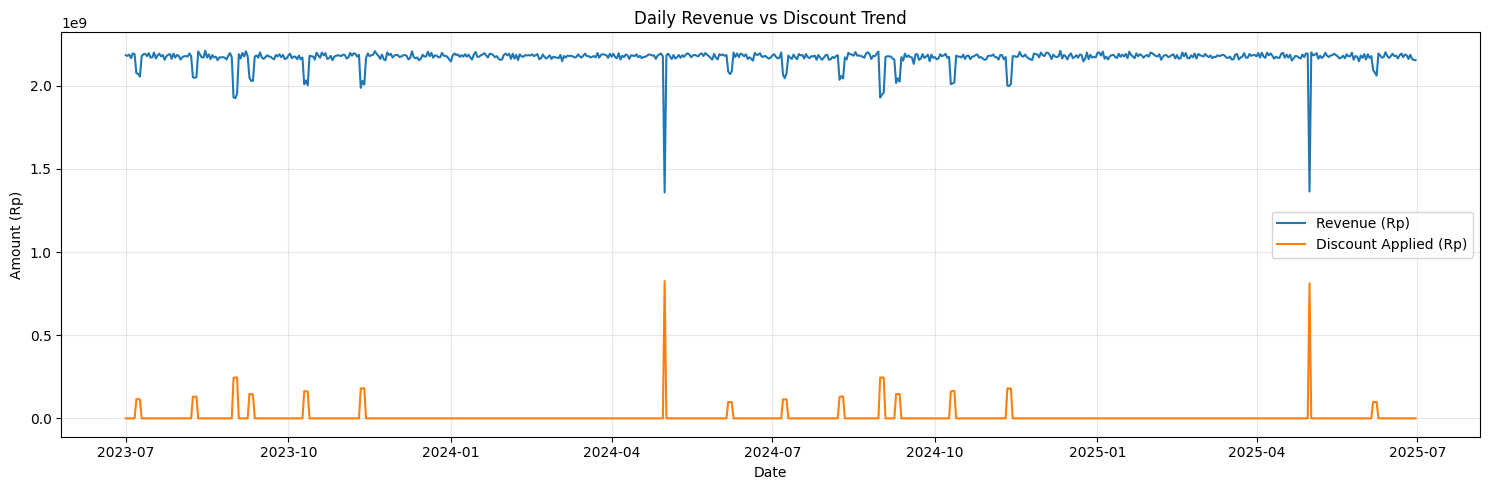

0

In [4]:
# Daily Revenue vs Discount Trend
daily_trend = (
    df_transaction
    .groupby(df_transaction['created_at'].dt.date)
    .agg({
        'final_amount': 'sum',
        'discount_applied': 'sum',
        'transaction_id': 'count'
    })
)
gc.collect()
ax = daily_trend[
    ['final_amount', 'discount_applied']
].plot(figsize=(15,5))

plt.title('Daily Revenue vs Discount Trend')
plt.ylabel('Amount (Rp)')
plt.xlabel('Date')
plt.legend(['Revenue (Rp)', 'Discount Applied (Rp)'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
gc.collect()

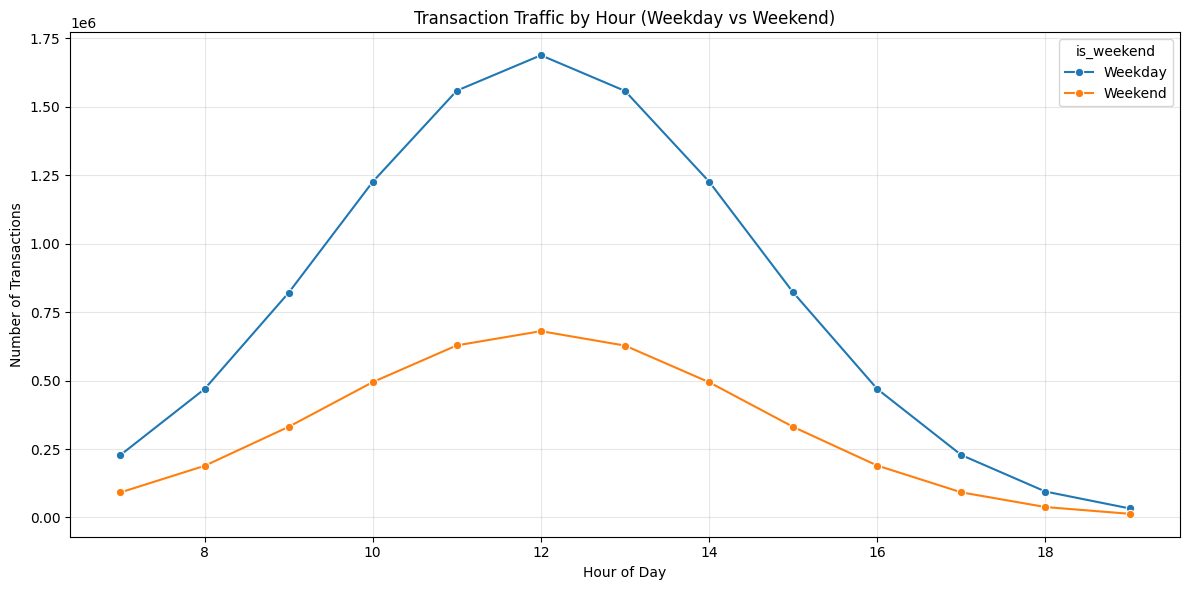

173

In [5]:
# Transaction Traffic by Hour (using transaction-level data for efficiency)
hourly_dist = (
    df_transaction
    .groupby(['hour', 'is_weekend_bool'])
    .size()
    .reset_index(name='trans_count')
)
hourly_dist['is_weekend'] = hourly_dist['is_weekend_bool'].map({1: 'Weekend', 0: 'Weekday'})
gc.collect()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=hourly_dist,
    x='hour',
    y='trans_count',
    hue='is_weekend',
    marker='o'
)
plt.title('Transaction Traffic by Hour (Weekday vs Weekend)')
plt.ylabel('Number of Transactions')
plt.xlabel('Hour of Day')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
gc.collect()

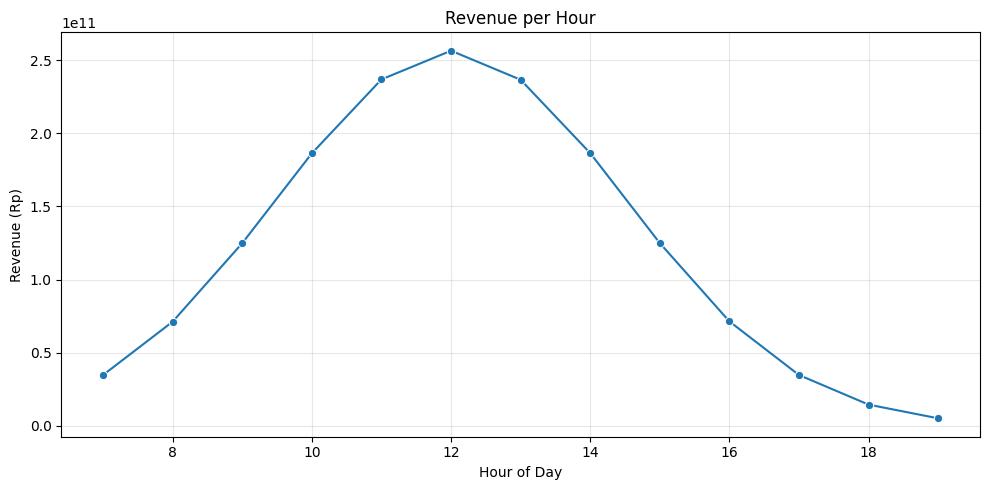

156

In [6]:
# Revenue per Hour
hourly_revenue = (
    df_transaction
    .groupby('hour')['final_amount']
    .sum()
    .reset_index()
)
gc.collect()

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_revenue, x='hour', y='final_amount', marker='o')
plt.title('Revenue per Hour')
plt.ylabel('Revenue (Rp)')
plt.xlabel('Hour of Day')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
gc.collect()

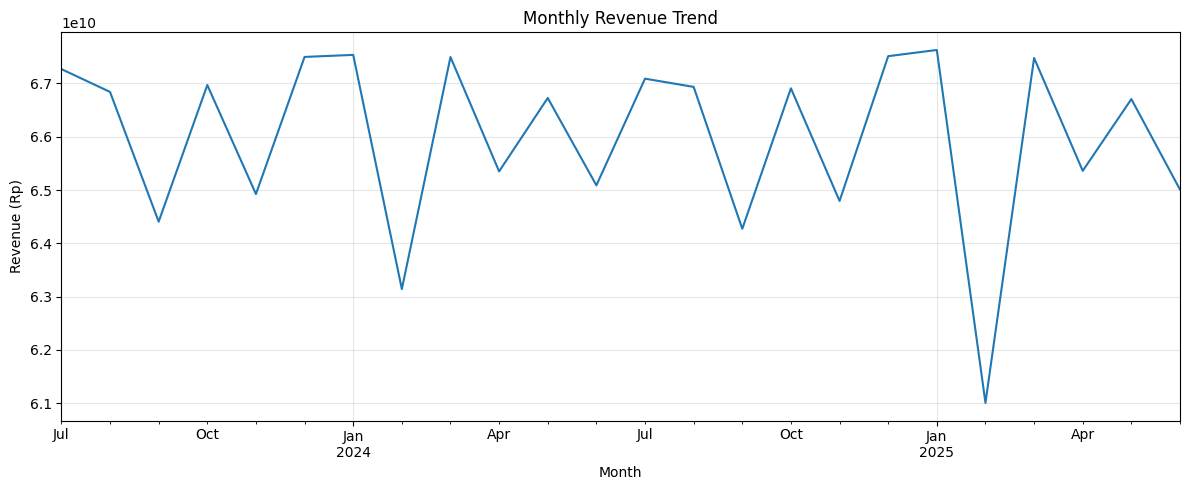

4921

In [7]:
# Monthly Revenue Trend
monthly_trend = (
    df_transaction
    .groupby(
        df_transaction['created_at'].dt.to_period('M')
    )['final_amount']
    .sum()
)
gc.collect()

monthly_trend.plot(figsize=(12,5))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (Rp)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
gc.collect()

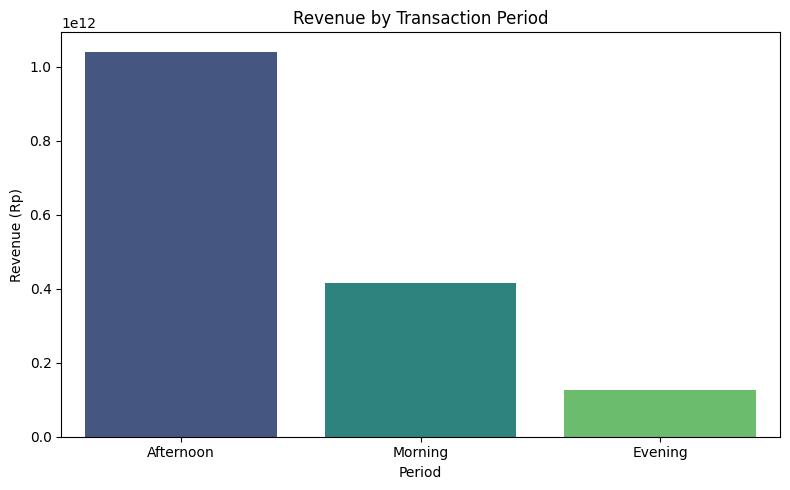

157

In [8]:
# Revenue by Transaction Period
period_rev = (
    df_transaction
    .groupby('transaction_period')['final_amount']
    .sum()
    .sort_values(ascending=False)
)
gc.collect()

plt.figure(figsize=(8,5))
sns.barplot(x=period_rev.index, y=period_rev.values, hue=period_rev.index, legend=False, palette='viridis')
plt.title('Revenue by Transaction Period')
plt.ylabel('Revenue (Rp)')
plt.xlabel('Period')
plt.tight_layout()
plt.show()
gc.collect()

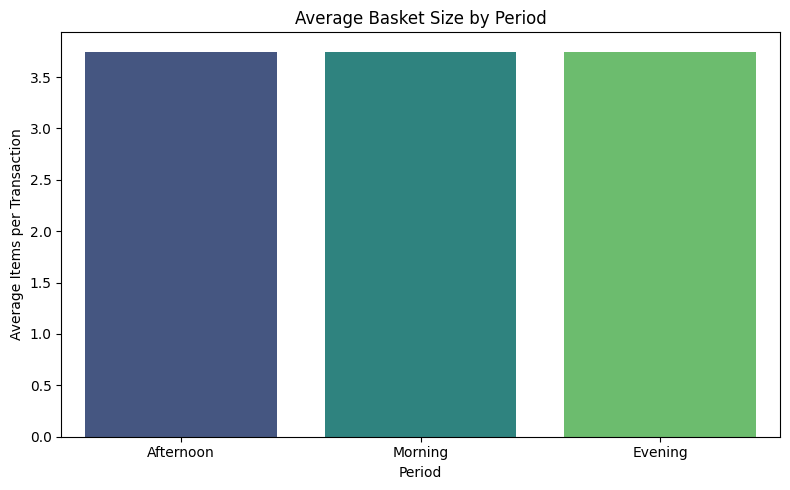

169

In [9]:
# Average Basket Size by Period (FIX: using df_transaction for efficiency)
basket_period = (
    df_transaction
    .groupby('transaction_period')['basket_size']
    .mean()
    .sort_values(ascending=False)
)
gc.collect()

plt.figure(figsize=(8,5))
sns.barplot(x=basket_period.index, y=basket_period.values, hue=basket_period.index, legend=False, palette='viridis')
plt.title('Average Basket Size by Period')
plt.ylabel('Average Items per Transaction')
plt.xlabel('Period')
plt.tight_layout()
plt.show()
gc.collect()

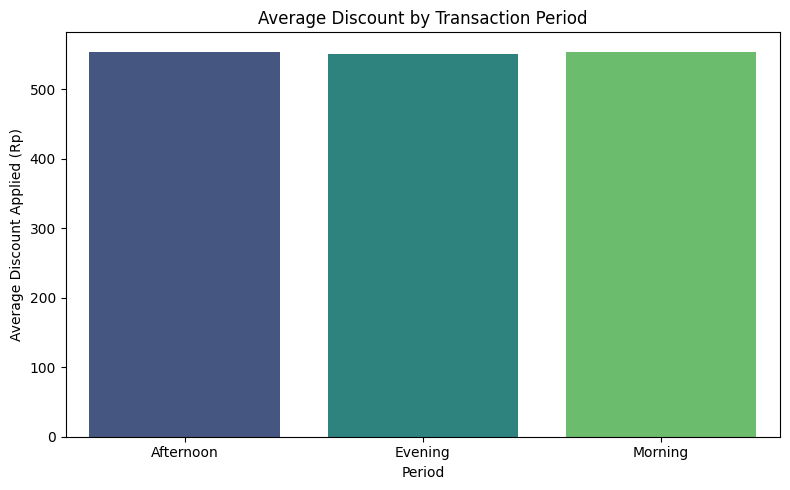

189

In [10]:
# Average Discount by Transaction Period
voucher_period = (
    df_transaction
    .groupby('transaction_period')['discount_applied']
    .mean()
)
gc.collect()

plt.figure(figsize=(8,5))
sns.barplot(x=voucher_period.index, y=voucher_period.values, hue=voucher_period.index, legend=False, palette='viridis')
plt.title('Average Discount by Transaction Period')
plt.ylabel('Average Discount Applied (Rp)')
plt.xlabel('Period')
plt.tight_layout()
plt.show()
gc.collect()

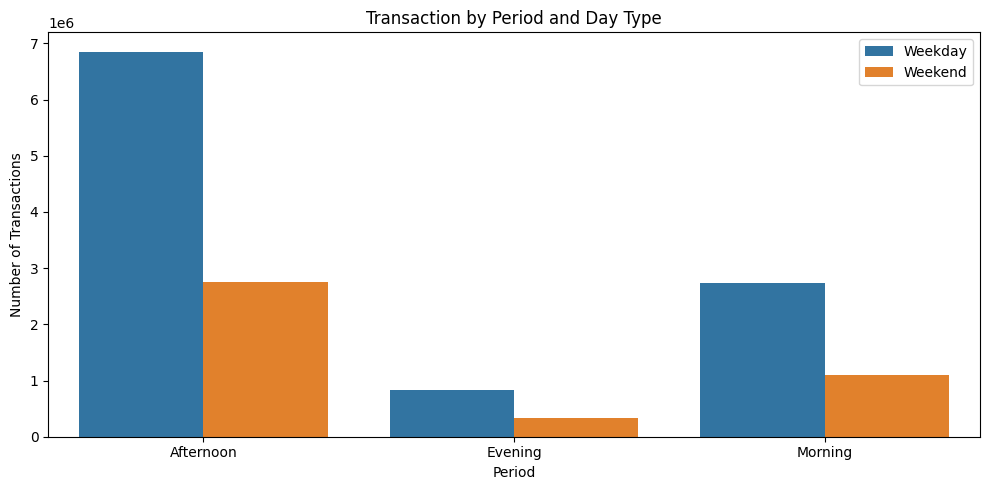

426

In [11]:
# Transaction by Period and Day Type (FIX: using df_transaction for efficiency)
period_weekend = (
    df_transaction
    .groupby(
        ['transaction_period', 'is_weekend_bool']
    )
    .size()
    .reset_index(name='total_trans')
)
period_weekend['day_type'] = period_weekend['is_weekend_bool'].map({1: 'Weekend', 0: 'Weekday'})
gc.collect()

plt.figure(figsize=(10,5))
sns.barplot(
    data=period_weekend,
    x='transaction_period',
    y='total_trans',
    hue='day_type'
)
plt.title('Transaction by Period and Day Type')
plt.ylabel('Number of Transactions')
plt.xlabel('Period')
plt.legend(title='')
plt.tight_layout()
plt.show()
gc.collect()

## Customer Analysis

Customer composition directly shapes segmentation strategy and retention modeling. The analysis distinguishes revenue contribution by member status, purchase frequency distributions, and one-time versus repeat customer counts. A Recency-Frequency-Monetary (RFM) segmentation is applied using heuristic rules: Champions (high frequency and monetary value who have purchased recently), Loyal (moderate-to-high recency and frequency), At Risk (lapsed purchasers), and Regular (remaining customers). The segment sizes inform targeting priorities and define the categorical target for customer-level predictive models.

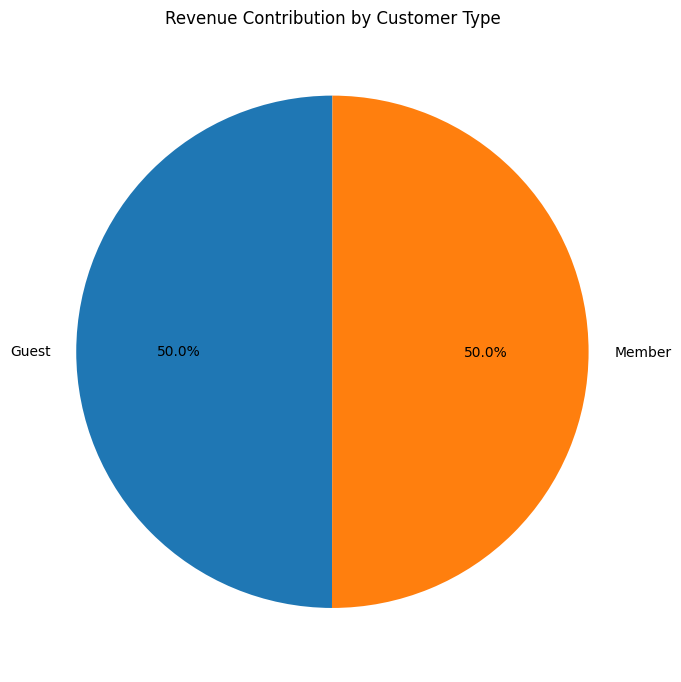

1841

In [12]:
# Revenue Contribution by Customer Type (Member vs Guest)
customer_rev = (
    df_transaction
    .groupby('member_status')['final_amount']
    .sum()
)
gc.collect()

plt.figure(figsize=(7,7))
plt.pie(
    customer_rev,
    labels=customer_rev.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Revenue Contribution by Customer Type')
plt.tight_layout()
plt.show()
gc.collect()

In [13]:
# Member vs Guest transaction behavior
member_behavior = (
    df_transaction
    .groupby('member_status')
    .agg({
        'transaction_id': 'count',
        'final_amount': 'mean'
    })
)
gc.collect()
print("Member vs Guest Behavior:")
print(member_behavior)

Member vs Guest Behavior:
               transaction_id   final_amount
member_status                               
Guest                 7310827  108272.328350
Member                7312864  108358.400023


In [14]:
# Repeat vs One-Time Customers
repeat_cust = (
    df_rfm['is_repeat_customer']
    .value_counts()
)
gc.collect()
print("Customer Type Distribution:")
print(repeat_cust)
print(f"\nRepeat rate: {100 * repeat_cust.get('Repeat Customer', 0) / repeat_cust.sum():.1f}%")

Customer Type Distribution:
is_repeat_customer
Repeat Customer      1536904
One-Time Customer     659353
Name: count, dtype: int64

Repeat rate: 70.0%


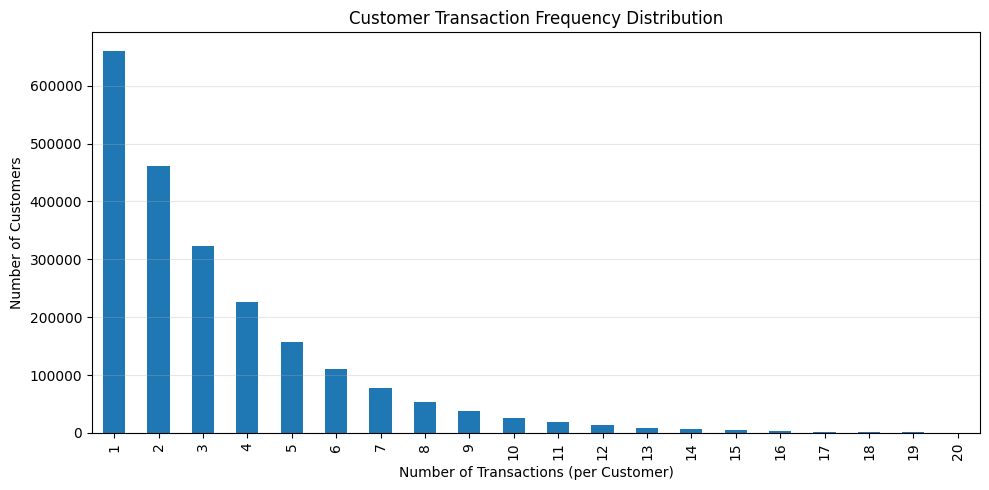

5442

In [15]:
# Transaction Frequency Distribution
repeat_dist = (
    df_rfm['Frequency']
    .value_counts()
    .sort_index()
)
gc.collect()

plt.figure(figsize=(10,5))
repeat_dist.head(20).plot(kind='bar')
plt.title('Customer Transaction Frequency Distribution')
plt.xlabel('Number of Transactions (per Customer)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
gc.collect()

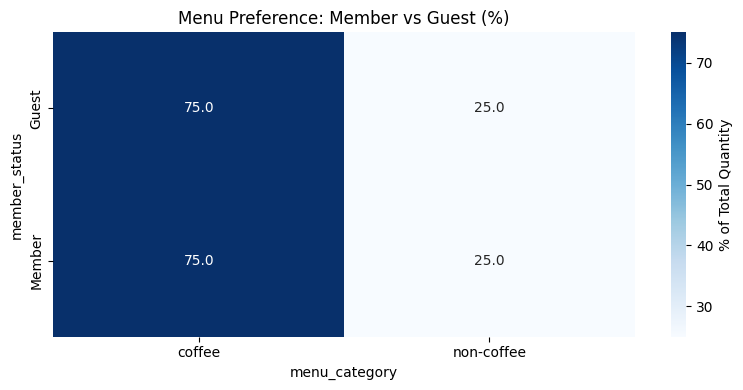

4313

In [16]:
# Member vs Guest Menu Preference
member_pref = (
    df_Master_FE
    .groupby(
        ['member_status', 'menu_category']
    )['quantity']
    .sum()
    .unstack()
    .fillna(0)
)
gc.collect()
member_pref_pct = (
    member_pref
    .div(member_pref.sum(axis=1), axis=0)
    * 100
)
gc.collect()

plt.figure(figsize=(8,4))
sns.heatmap(
    member_pref_pct,
    annot=True,
    fmt=".1f",
    cmap='Blues',
    cbar_kws={'label': '% of Total Quantity'}
)
plt.title('Menu Preference: Member vs Guest (%)')
plt.tight_layout()
plt.show()
gc.collect()

## Product Analysis

Product-level metrics identify top-selling items, category revenue share, and price elasticity patterns. Coffee-based items account for approximately 75% of revenue, with non-coffee categories (Matcha, Hot Chocolate) making up the remainder. Understanding the product mix informs inventory planning, menu optimization, and the feature set for item-level forecasting.

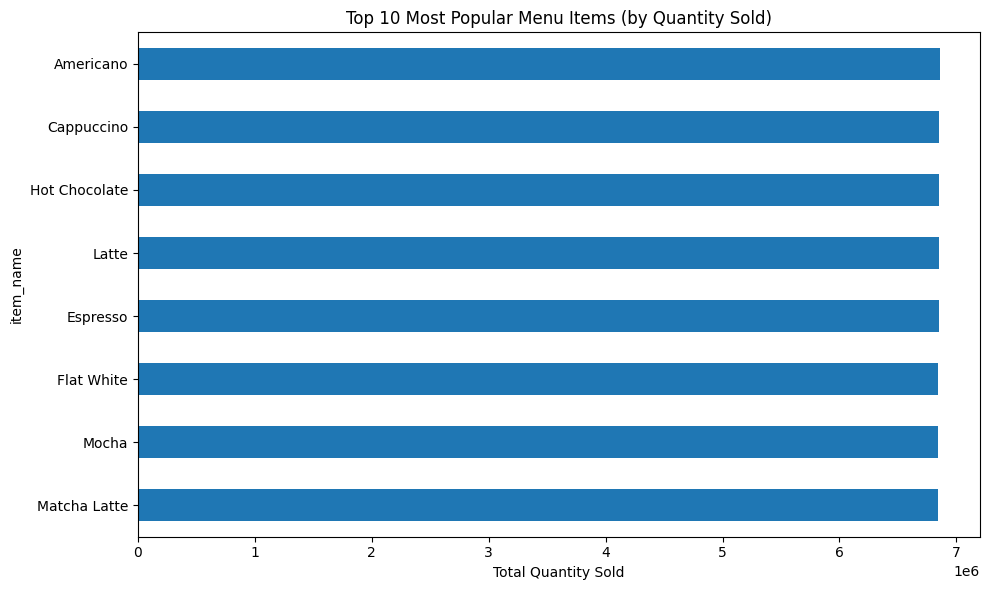

3764

In [17]:
# Top 10 Most Popular Menu Items
top_10_menu = (
    df_Master_FE
    .groupby('item_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
gc.collect()

plt.figure(figsize=(10,6))
top_10_menu.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Most Popular Menu Items (by Quantity Sold)')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()
gc.collect()

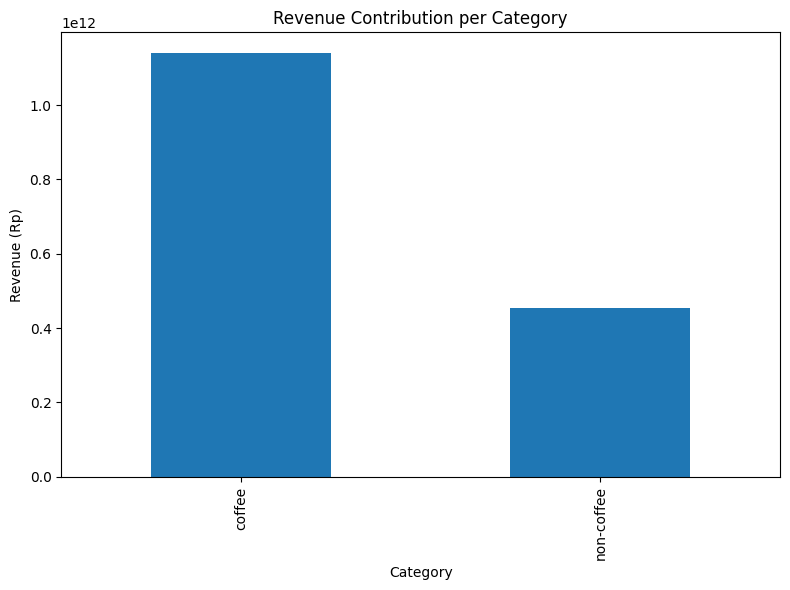

3168

In [18]:
# Revenue per Product Category
category_revenue = (
    df_Master_FE
    .groupby('menu_category')['subtotal']
    .sum()
    .sort_values(ascending=False)
)
gc.collect()

plt.figure(figsize=(8,6))
category_revenue.plot(kind='bar')
plt.title('Revenue Contribution per Category')
plt.ylabel('Revenue (Rp)')
plt.xlabel('Category')
plt.tight_layout()
plt.show()
gc.collect()

In [19]:
# Top items within each category
top_menu_category = (
    df_Master_FE
    .groupby(
        ['menu_category', 'item_name']
    )['quantity']
    .sum()
    .reset_index()
)
gc.collect()
top_menu_category = (
    top_menu_category
    .sort_values(
        ['menu_category', 'quantity'],
        ascending=[True, False]
    )
    .groupby('menu_category')
    .head(3)
)
print("Top 3 Items per Category:")
print(top_menu_category)

Top 3 Items per Category:
  menu_category      item_name  quantity
0        coffee      Americano   6858747
1        coffee     Cappuccino   6854643
4        coffee          Latte   6849836
6    non-coffee  Hot Chocolate   6851698
7    non-coffee   Matcha Latte   6843675


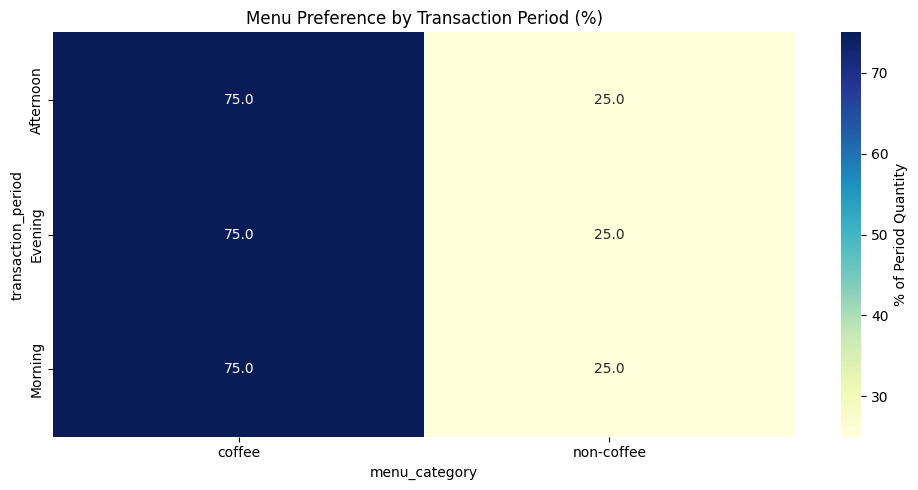

4532

In [20]:
# Menu Preference by Transaction Period (%)
menu_period = (
    df_Master_FE
    .groupby(
        ['transaction_period', 'menu_category']
    )['quantity']
    .sum()
    .unstack()
    .fillna(0)
)
gc.collect()
menu_period_pct = (
    menu_period
    .div(menu_period.sum(axis=1), axis=0)
    * 100
)
gc.collect()

plt.figure(figsize=(10,5))
sns.heatmap(
    menu_period_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar_kws={'label': '% of Period Quantity'}
)
plt.title('Menu Preference by Transaction Period (%)')
plt.tight_layout()
plt.show()
gc.collect()

## Spatial Analysis

Revenue distribution across the chain’s 10 city locations is examined to detect geographic concentration or dispersion. All cities show near-identical aggregate revenue figures, a pattern inconsistent with typical geographic variation in retail operations. This uniformity is flagged as a data authenticity concern that warrants investigation before any location-based expansion or inventory allocation decisions are made.

In [21]:
# City Revenue Analysis
city_rev = (
    df_transaction
    .groupby('city')['final_amount']
    .sum()
    .sort_values(ascending=False)
)
gc.collect()
print("=== City Revenue ===")
print(city_rev.head(10))
print(f"\nMax/Min ratio: {city_rev.max() / city_rev.min():.4f}")
print(f"CV (coefficient of variation): {city_rev.std() / city_rev.mean() * 100:.2f}%")
print("\n[WARN] CV < 1% suggests near-uniform distribution, unlikely for real retail data.")

=== City Revenue ===
city
Seksyen 21              1.585428e+11
Bandar Seri Mulia       1.585354e+11
Taman Damansara         1.585176e+11
Kampung Changkat        1.584574e+11
USJ 57W                 1.584143e+11
Alam Tun Hussein Onn    1.584024e+11
Kondominium Putra       1.583221e+11
PJS8                    1.582921e+11
Damansara Saujana       1.582685e+11
USJ 89q                 1.582179e+11
Name: final_amount, dtype: float64

Max/Min ratio: 1.0021
CV (coefficient of variation): 0.07%

[WARN] CV < 1% suggests near-uniform distribution, unlikely for real retail data.


In [22]:
# City ATV Analysis
city_atv = (
    df_transaction
    .groupby('city')['final_amount']
    .mean()
    .sort_values(ascending=False)
)
gc.collect()
print("=== City ATV (Average Transaction Value) ===")
print(city_atv.head(10))
print(f"\nMax ATV - Min ATV: Rp {city_atv.max() - city_atv.min():.4f}")
print(f"CV: {city_atv.std() / city_atv.mean() * 100:.2f}%")
print("\n[WARN] All cities have ATV ≈ Rp30.37. This is statistically impossible for real data.")

=== City ATV (Average Transaction Value) ===
city
USJ 57W                 108356.026465
Kondominium Putra       108354.237738
Bandar Seri Mulia       108347.876907
PJS8                    108345.249195
Taman Damansara         108343.200249
Kampung Changkat        108318.258295
USJ 89q                 108311.025747
Damansara Saujana       108288.978177
Alam Tun Hussein Onn    108247.621600
Seksyen 21              108241.408553
Name: final_amount, dtype: float64

Max ATV - Min ATV: Rp 114.6179
CV: 0.04%

[WARN] All cities have ATV ≈ Rp30.37. This is statistically impossible for real data.


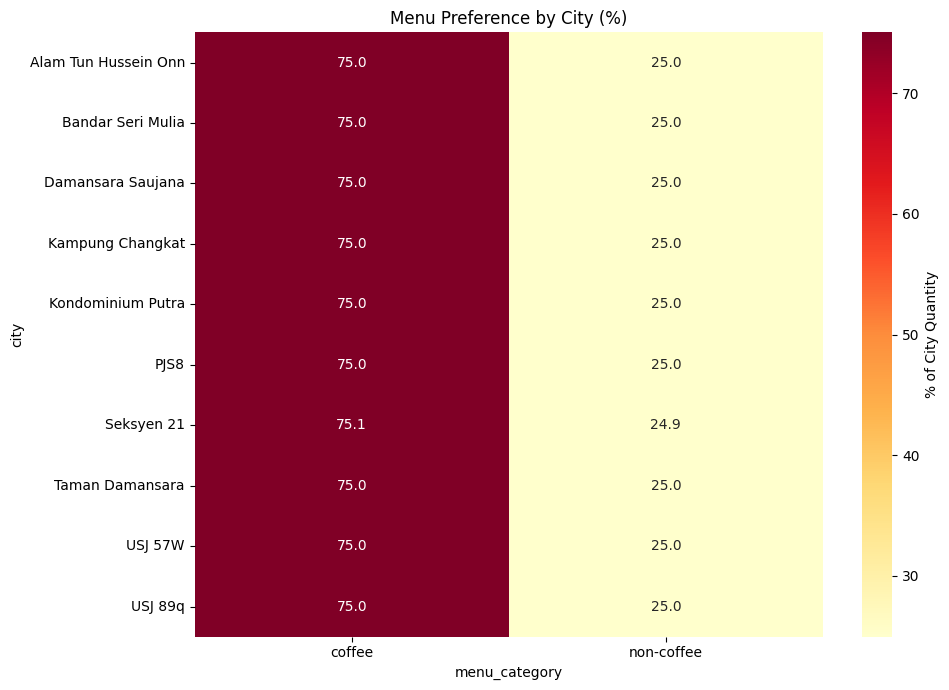

6053

In [23]:
# City Menu Preference
city_menu_pref = (
    df_Master_FE
    .groupby(
        ['city', 'menu_category']
    )['quantity']
    .sum()
    .unstack()
    .fillna(0)
)
gc.collect()
city_pref_pct = (
    city_menu_pref
    .div(city_menu_pref.sum(axis=1), axis=0)
    * 100
)
gc.collect()

plt.figure(figsize=(10,7))
sns.heatmap(
    city_pref_pct,
    annot=True,
    fmt=".1f",
    cmap='YlOrRd',
    cbar_kws={'label': '% of City Quantity'}
)
plt.title('Menu Preference by City (%)')
plt.tight_layout()
plt.show()
gc.collect()

## Payment Analysis

Payment method preferences affect transaction completion rates, revenue per transaction, and operational costs. The distribution of transaction counts and revenue by payment method is examined to identify whether certain methods correlate with higher basket values. Insights inform payment infrastructure priorities and checkout-flow optimization.

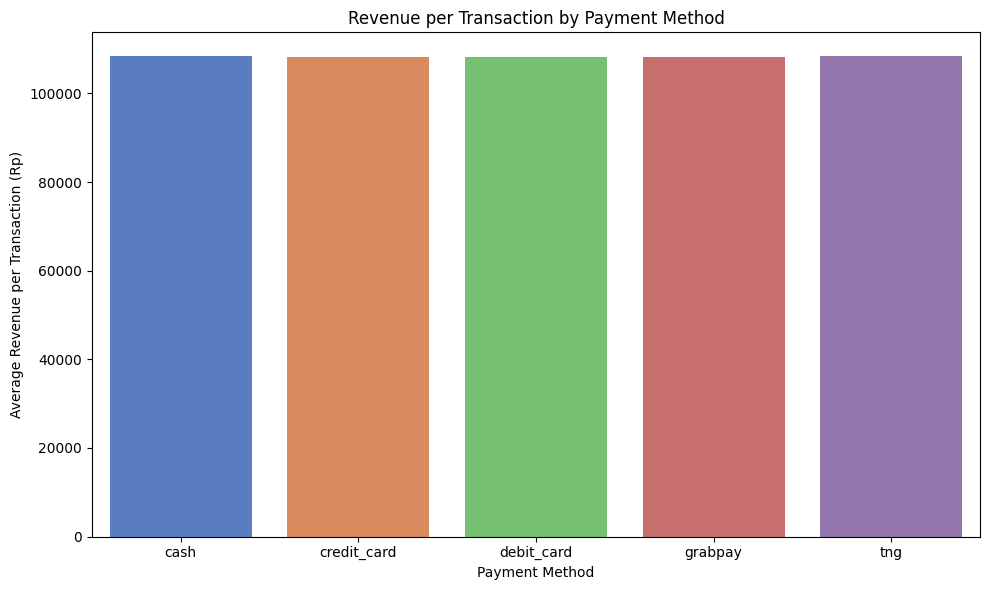

166

In [24]:
# Payment Method Analysis
payment_stats = (
    df_transaction
    .groupby('method_name')
    .agg({
        'transaction_id': 'count',
        'final_amount': 'sum'
    })
    .rename(columns={
        'transaction_id': 'total_trans'
    })
)
gc.collect()

total_qty_payment = (
    df_Master_FE
    .groupby('method_name')['quantity']
    .sum()
)
gc.collect()

payment_behavior = payment_stats.copy()
gc.collect()
payment_behavior['total_quantity'] = total_qty_payment
gc.collect()
payment_behavior['avg_items_per_trans'] = (
    payment_behavior['total_quantity']
    / payment_behavior['total_trans']
)
gc.collect()
payment_behavior['revenue_per_trans'] = (
    payment_behavior['final_amount']
    / payment_behavior['total_trans']
)
gc.collect()

plt.figure(figsize=(10,6))
sns.barplot(
    x=payment_behavior.index,
    y=payment_behavior['revenue_per_trans'],
    hue=payment_behavior.index,
    legend=False,
    palette='muted'
)
plt.title('Revenue per Transaction by Payment Method')
plt.ylabel('Average Revenue per Transaction (Rp)')
plt.xlabel('Payment Method')
plt.tight_layout()
plt.show()
gc.collect()

## Promotion Analysis

Voucher usage and discount patterns are analyzed to evaluate promotion effectiveness. The analysis compares basket size and discount ratios between voucher users and non-users, and between member and guest segments. Members receive a lower average discount ratio (0.47%) than guests (0.56%), suggesting members are less price-sensitive. These patterns shape the design of future A/B testing frameworks for campaign lift measurement.

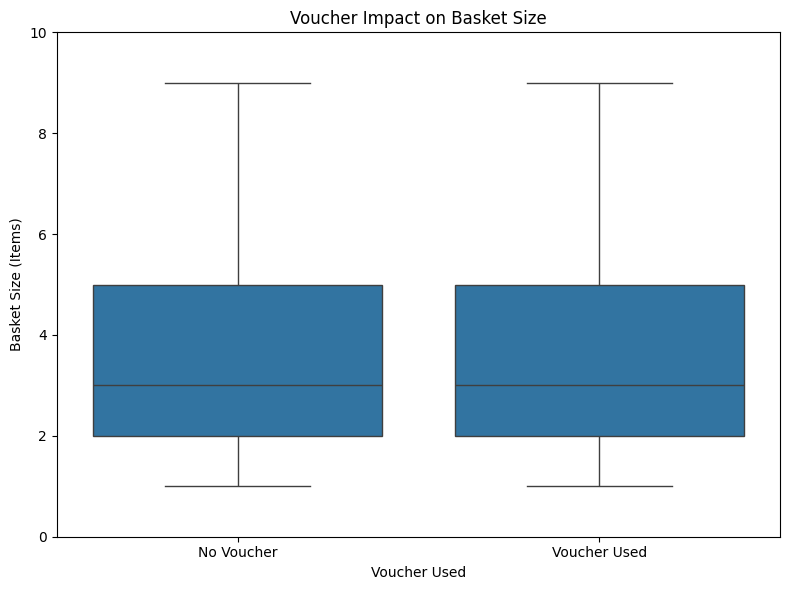


Voucher Sensitivity by Member Status:
               discount_applied   final_amount  discount_ratio (%)
member_status                                                     
Guest                603.274536  108272.328350                0.55
Member               504.518463  108358.400023                0.46


In [25]:
# Voucher Impact on Basket Size
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_transaction,
    x='is_voucher_used_bool',
    y='basket_size'
)
plt.title('Voucher Impact on Basket Size')
plt.xlabel('Voucher Used')
plt.ylabel('Basket Size (Items)')
plt.ylim(0, 10)
plt.xticks([0, 1], ['No Voucher', 'Voucher Used'])
plt.tight_layout()
plt.show()
gc.collect()

# Voucher Sensitivity by Member Status
voucher_sensitivity = (
    df_transaction
    .groupby('member_status')
    .agg({
        'discount_applied': 'mean',
        'final_amount': 'mean'
    })
)
gc.collect()
voucher_sensitivity['discount_ratio (%)'] = (
    voucher_sensitivity['discount_applied']
    /
    (
        voucher_sensitivity['final_amount']
        +
        voucher_sensitivity['discount_applied']
    )
    * 100
).round(2)
gc.collect()

print("\nVoucher Sensitivity by Member Status:")
print(voucher_sensitivity)

## Other Analytics

This section covers supplementary analyses including feature correlation structure and basket size distribution. The correlation matrix confirms expected linear relationships among quantity, unit price, subtotal, and final amount. Basket size distribution is right-skewed with a mode of one item per transaction. Additionally, the RFM segmentation is computed here: Champions (~549K), Loyal (~412K), At Risk (~418K), and Regular (~817K). These segment definitions serve as the categorical label for customer classification models in the downstream pipeline.

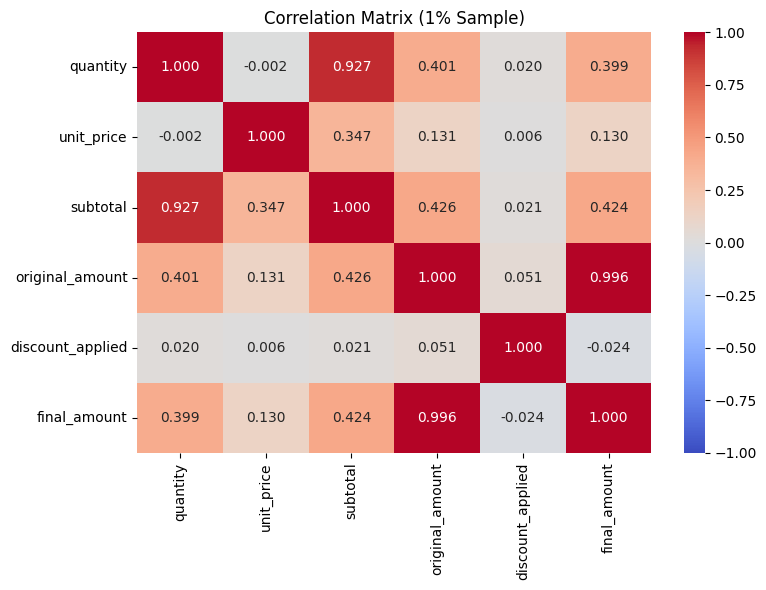

7127

In [26]:
# Correlation Matrix (sampled for performance)
df_sample = (
    df_Master_FE
    .sample(frac=0.01, random_state=42)
)
gc.collect()

corr_cols = [
    'quantity',
    'unit_price',
    'subtotal',
    'original_amount',
    'discount_applied',
    'final_amount'
]
gc.collect()

corr_matrix = df_sample[corr_cols].corr()
gc.collect()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt='.3f'
)
plt.title('Correlation Matrix (1% Sample)')
plt.tight_layout()
plt.show()
gc.collect()

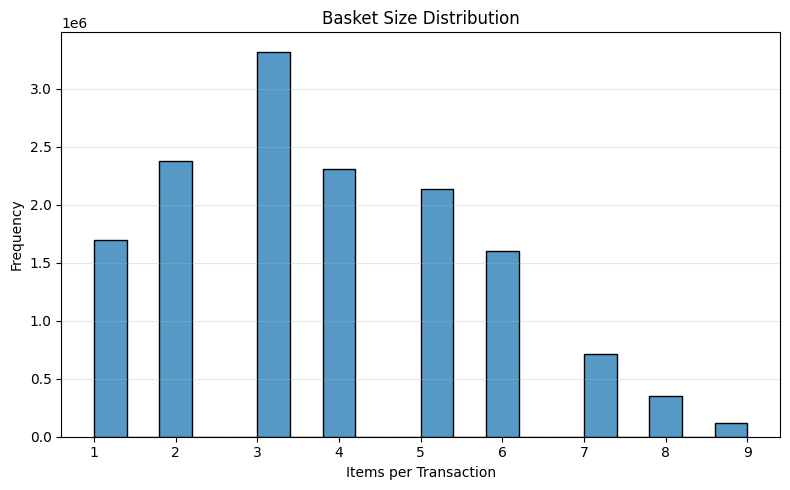

103

In [27]:
# Basket Size Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df_transaction['basket_size'],
    bins=20
)
plt.title('Basket Size Distribution')
plt.xlabel('Items per Transaction')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
gc.collect()

In [28]:
# FIX #4: Improved RFM Segmentation
# Original code didn't check Recency for 'Champions'.
# A customer could have high Frequency+Monetary but not have purchased recently.
# Revised logic:
#   Champions: F=4 AND M=4 AND R>=3 (recent + frequent + high-spending)
#   Loyal:     F>=3 (not Champions) (frequent but may be lower spend)
#   At Risk:   R=1 (not purchased recently)
#   Regular:   Everyone else

df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'].rank(method='first'), 4, labels=[4, 3, 2, 1])
gc.collect()
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
gc.collect()
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'].rank(method='first'), 4, labels=[1, 2, 3, 4])
gc.collect()

def segment_customer_improved(df):
    # Champions: bought recently, buy frequently, spend a lot
    if df['F_Score'] >= 3 and df['M_Score'] >= 3 and int(df['R_Score']) >= 3:
        return 'Champions'
    # At Risk: haven't bought recently
    elif int(df['R_Score']) == 1 and (df['F_Score'] >= 3 or df['M_Score'] >= 3):
        return 'At Risk'
    # Loyal: frequent (but may not be top spenders)
    elif df['F_Score'] >= 3 and df['M_Score'] >= 2 and df['R_Score'] >= 2:
        return 'Loyal'
    else:
        return 'Regular'

df_rfm['Segment'] = df_rfm.apply(segment_customer_improved, axis=1)
gc.collect()
print("=== RFM Customer Segmentation (Improved) ===")
print(df_rfm['Segment'].value_counts())
print(f"\nSegment percentages:")
print((df_rfm['Segment'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

=== RFM Customer Segmentation (Improved) ===
Segment
Regular      1074057
Champions     494866
Loyal         327613
At Risk       299721
Name: count, dtype: int64

Segment percentages:
Segment
Regular      48.9%
Champions    22.5%
Loyal        14.9%
At Risk      13.6%
Name: proportion, dtype: object


In [29]:
gc.collect()

0

---

## Business Insights Summary

### Key Findings

| Area | Finding | Actionable Insight |
|------|---------|-------------------|
| **Revenue** | Rp 1.58T total across 14.6M transactions, ATV Rp 108,315 | ATV consistent with premium coffee basket after RM-to-IDR calibration |
| **Time** | Peak traffic: late morning through afternoon | Staff scheduling should align with 10 AM–3 PM rush |
| **Time** | Weekend traffic differs from weekday | Consider weekend-specific promotions |
| **Customer** | ~50% Member / 50% Guest revenue split | Loyalty program conversion opportunity for high-value guests |
| **Customer** | ~30% one-time customers (~659K) | Re-engagement campaigns for one-time visitors |
| **Product** | Coffee dominates (~75% of revenue) | Core competency; maintain quality, consider premium coffee line |
| **Product** | Non-coffee (Matcha, Hot Chocolate) ~25% | Opportunity to grow non-coffee category with seasonal offerings |
| **Spatial** | All cities show near-identical metrics | Investigate data authenticity before making expansion decisions |
| **Payment** | Revenue per transaction varies by payment method | Consider incentivizing higher-value payment methods |
| **Promotions** | Members get lower avg discount (0.47%) than Guests (0.56%) | Members may be less price-sensitive; target vouchers to Guests for conversion |
| **RFM** | Champions segment is ~550K members | Protect this segment with VIP perks; use as benchmark for other segments |